# Herding versus crowding: NetworkX version

This experiment uses explicit NetworkX graph objects to represent two manager--security bipartite networks.

- **Herding is a process:** both managers make the same trade even though their other holdings differ.
- **Crowding is a state:** the managers are observed with highly overlapping portfolios at one date.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D


project_root = Path.cwd().resolve()

while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()
print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.6.1


In [2]:
managers = ["A", "B", "C"]
securities = ["1", "2", "3", "4", "5"]
herding_holdings = [("A", "2"), ("B", "3"), ("C", "4"), ("C", "5")]
herding_trades = [(manager, "1") for manager in managers]

crowding_shared = [
    (manager, security)
    for manager in managers
    for security in ("1", "2", "3")
]
crowding_other = [("A", "4"), ("C", "5")]

herding_graph = nx.DiGraph()
herding_graph.add_nodes_from(managers, bipartite=0, node_type="manager")
herding_graph.add_nodes_from(securities, bipartite=1, node_type="security")
herding_graph.add_edges_from(herding_holdings, relation="holding")
herding_graph.add_edges_from(herding_trades, relation="trade")

crowding_graph = nx.Graph()
crowding_graph.add_nodes_from(managers, bipartite=0, node_type="manager")
crowding_graph.add_nodes_from(securities, bipartite=1, node_type="security")
crowding_graph.add_edges_from(crowding_shared, relation="shared holding")
crowding_graph.add_edges_from(crowding_other, relation="other holding")

layout_graph = nx.compose(herding_graph.to_undirected(), crowding_graph)
shared_positions = nx.spring_layout(
    layout_graph,
    seed=7,
    k=1.75,
    iterations=300,
)
print(f"Herding graph: {herding_graph.number_of_nodes()} nodes, {herding_graph.number_of_edges()} edges")
print(f"Crowding graph: {crowding_graph.number_of_nodes()} nodes, {crowding_graph.number_of_edges()} edges")

Herding graph: 8 nodes, 7 edges
Crowding graph: 8 nodes, 11 edges


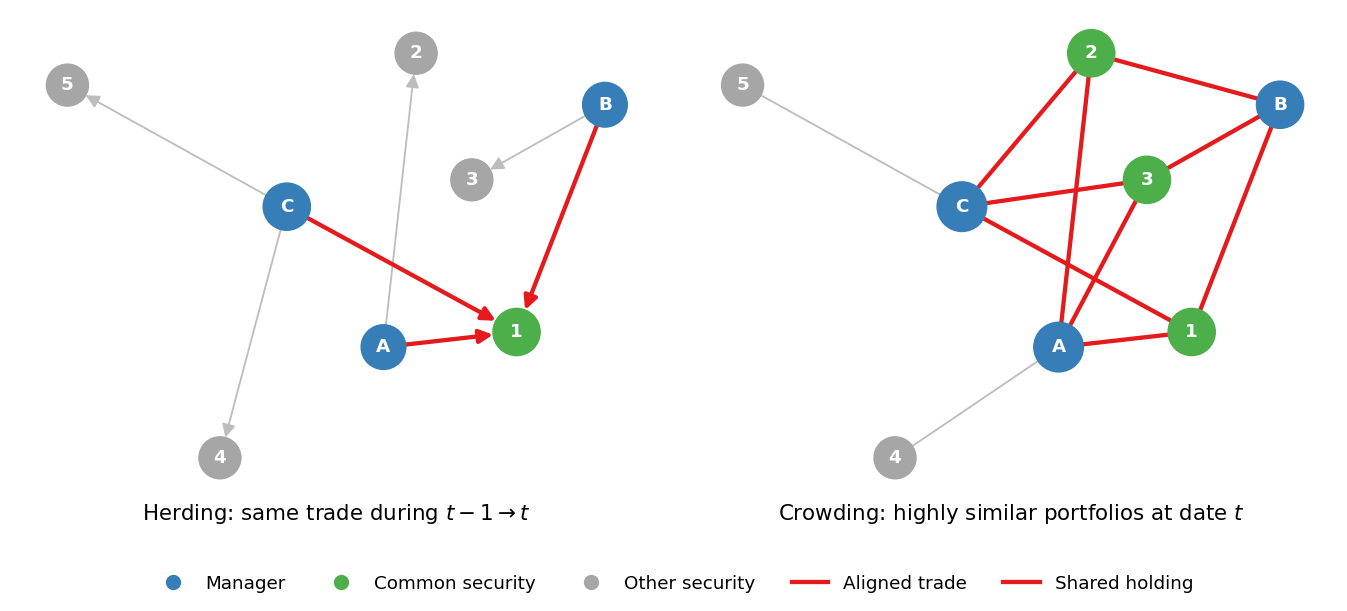

In [3]:
def get_node_color(graph, node):
    if graph.nodes[node]["node_type"] == "manager":
        return COLOR_PALETTE[0]

    relations = {
        data["relation"]
        for node_1, node_2, data in graph.edges(data=True)
        if node in (node_1, node_2)
    }
    is_common = bool(relations & {"trade", "shared holding"})
    return COLOR_PALETTE[2] if is_common else "#A6A6A6"


def get_edge_color(graph, node_1, node_2):
    relation = graph.edges[node_1, node_2]["relation"]
    if relation == "trade":
        return COLOR_PALETTE[1]
    if relation == "shared holding":
        return COLOR_PALETTE[1]
    return "#BDBDBD"


def get_edge_weight(graph, node_1, node_2):
    relation = graph.edges[node_1, node_2]["relation"]
    return 2.8 if relation in {"trade", "shared holding"} else 1.2


def draw_graph(axis, graph, positions, caption):
    node_colors = [get_node_color(graph, node) for node in graph.nodes()]
    node_sizes = [650 + 100 * graph.degree(node) for node in graph.nodes()]
    edge_colors = [get_edge_color(graph, node_1, node_2) for node_1, node_2 in graph.edges()]
    edge_weights = [get_edge_weight(graph, node_1, node_2) for node_1, node_2 in graph.edges()]
    arrow_options = {}
    if graph.is_directed():
        arrow_options = {
            "arrows": True,
            "arrowsize": 18,
            "min_source_margin": 10,
            "min_target_margin": 10,
        }

    nx.draw(
        graph,
        pos=positions,
        node_color=node_colors,
        node_size=node_sizes,
        edge_color=edge_colors,
        width=edge_weights,
        with_labels=True,
        font_color="white",
        font_weight="bold",
        ax=axis,
        **arrow_options,
    )
    axis.text(
        0.5,
        -0.04,
        caption,
        transform=axis.transAxes,
        ha="center",
        fontsize=14,
        linespacing=1.4,
    )


figure, axes = plt.subplots(1, 2, figsize=(12.5, 5.5))
draw_graph(
    axes[0],
    herding_graph,
    shared_positions,
    r"Herding: same trade during $t-1 \rightarrow t$",
)
draw_graph(
    axes[1],
    crowding_graph,
    shared_positions,
    "Crowding: highly similar portfolios at date $t$",
)

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=COLOR_PALETTE[0], markeredgecolor="none", markersize=10, label="Manager"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=COLOR_PALETTE[2], markeredgecolor="none", markersize=10, label="Common security"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="#A6A6A6", markeredgecolor="none", markersize=10, label="Other security"),
    Line2D([0], [0], color=COLOR_PALETTE[1], linewidth=2.8, label="Aligned trade"),
    Line2D([0], [0], color=COLOR_PALETTE[1], linewidth=2.8, label="Shared holding"),
]
figure.legend(handles=legend_handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.03))
apply_matplotlib_layout(figure)
figure.subplots_adjust(bottom=0.15)
figure.savefig(paths.figures / "08_04_herding_vs_crowding_networkx.pdf")
plt.show()

## Interpretation

NetworkX makes the edge semantics explicit in the graph objects: directed trade edges encode herding, whereas undirected holding edges encode crowding. The right panel shows a strong form of portfolio-level crowding; identical portfolios are not required for a single security to be crowded.